中国实时音视频行业研究报告
https://report.iresearch.cn/report_pdf.aspx?id=4047

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

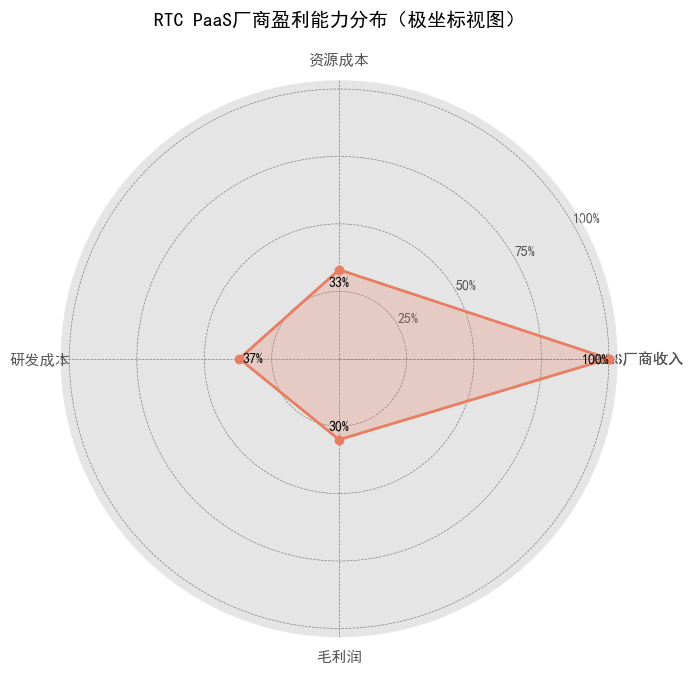

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 设置风格与配色
plt.style.use("ggplot")
sns.set_palette("Set2")

# 数据
categories = ["PaaS厂商收入", "资源成本", "研发成本", "毛利润"]
data = [100, 33, 37, 30]
colors = sns.color_palette("flare", len(data))  # 鲜艳渐变色系

# 极坐标图（雷达图变体）——仅一个维度，用饼图模拟也可以
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# 极坐标角度
angles = np.linspace(0, 2 * np.pi, len(data), endpoint=False).tolist()
# 闭合图形
data += data[:1]
angles += angles[:1]

# 绘图
ax.fill(angles, data, color=colors[0], alpha=0.25)
ax.plot(angles, data, color=colors[0], linewidth=2, linestyle="-", marker='o')

# 添加数据标注
for angle, value, label in zip(angles[:-1], data[:-1], categories):
    ax.text(
        angle,
        value - 5,  # 往外偏移一点防止与图形重合，可调节
        f"{value}%",
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

# 设置类别标签
categories += categories[:1]
ax.set_xticks(angles)
ax.set_xticklabels(categories, fontsize=11)

# 设置标题
plt.title("RTC PaaS厂商盈利能力分布（极坐标视图）", fontsize=14, fontweight="bold", pad=20)

# 配置坐标轴范围
ax.set_rlabel_position(30)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=10)
ax.grid(color="gray", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()


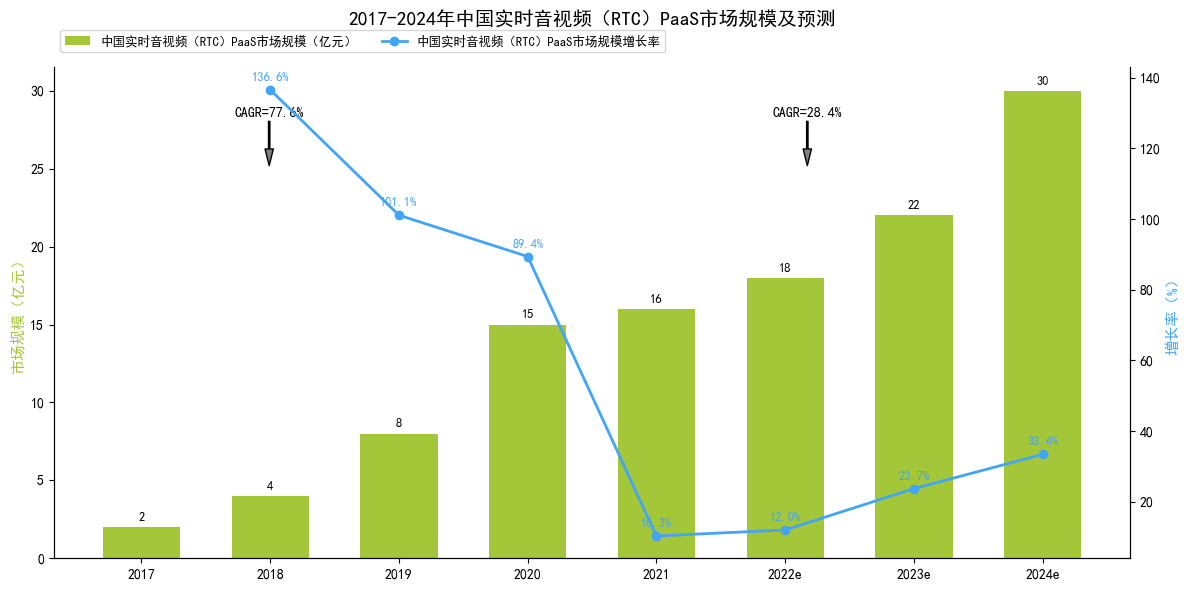

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 模拟数据（与原图趋势一致）
years = ["2017", "2018", "2019", "2020", "2021", "2022e", "2023e", "2024e"]
market_size = np.array([2, 4, 8, 15, 16, 18, 22, 30])  # 市场规模（亿元）
growth_rate = np.array([136.6, 101.1, 89.4, 10.3, 12.0, 23.7, 33.4])  # 增长率（%），注意长度比 years 少1（2017无增长率）

# 初始化双轴画布
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# 绘制柱状图（市场规模）
x = np.arange(len(years))
bar_width = 0.6
rects = ax1.bar(x, market_size, width=bar_width, label="中国实时音视频（RTC）PaaS市场规模（亿元）", color="#A4C639")

# 绘制折线图（增长率）
line, = ax2.plot(x[1:], growth_rate, marker="o", color="#42A5F5", label="中国实时音视频（RTC）PaaS市场规模增长率", linewidth=2)

# 添加市场规模标注（柱状图顶部）
for rect in rects:
    height = rect.get_height()
    ax1.annotate(f'{height}', 
                 xy=(rect.get_x() + rect.get_width()/2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9)

# 添加增长率标注（折线图点上方）
for i, rate in enumerate(growth_rate):
    ax2.annotate(f'{rate}%', 
                 xy=(x[i+1], rate),  # x 从2018开始（索引1）
                 xytext=(0, 5),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=9, color="#42A5F5")

# 添加 CAGR 标注（手动模拟箭头和文本）
ax1.annotate(
    "CAGR=77.6%", 
    xy=(0.2, 0.8), xycoords="axes fraction",
    xytext=(0.2, 0.9), textcoords="axes fraction",
    arrowprops=dict(facecolor='gray', width=1, headwidth=6),
    fontsize=10, ha='center'
)
ax1.annotate(
    "CAGR=28.4%", 
    xy=(0.7, 0.8), xycoords="axes fraction",
    xytext=(0.7, 0.9), textcoords="axes fraction",
    arrowprops=dict(facecolor='gray', width=1, headwidth=6),
    fontsize=10, ha='center'
)

# 坐标轴与图例配置
ax1.set_xticks(x)
ax1.set_xticklabels(years, fontsize=10)
ax1.set_ylabel("市场规模（亿元）", fontsize=11, color="#A4C639")
ax2.set_ylabel("增长率（%）", fontsize=11, color="#42A5F5")

# 合并图例（解决双轴图例重叠问题）
handles, labels = ax1.get_legend_handles_labels()
handles.append(line)
labels.append(line.get_label())
ax1.legend(handles, labels, loc="upper left", bbox_to_anchor=(0, 1.09), ncol=2, fontsize=9)

# 标题与美化
plt.title("2017-2024年中国实时音视频（RTC）PaaS市场规模及预测", fontsize=14, pad=30)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)
plt.tight_layout()

# 显示图表
plt.show()

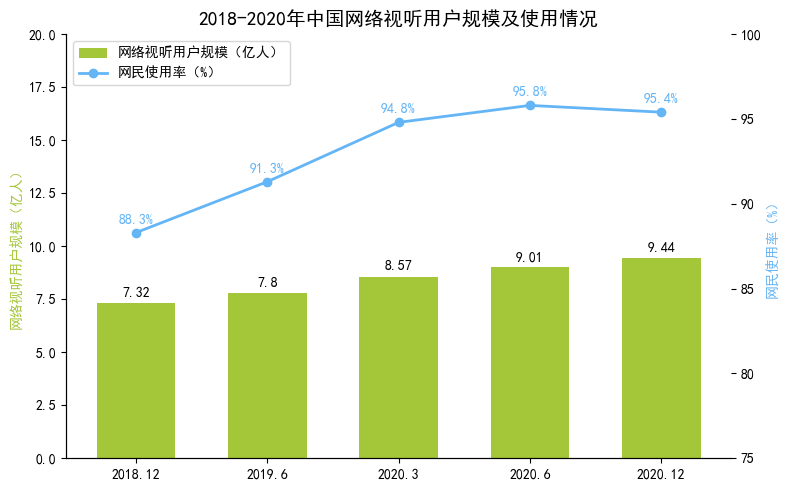

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 时间节点
years = ["2018.12", "2019.6", "2020.3", "2020.6", "2020.12"]
# 网络视听用户规模（亿人）
user_scale = [7.32, 7.8, 8.57, 9.01, 9.44]
# 网民使用率（%）
usage_rate = [88.3, 91.3, 94.8, 95.8, 95.4]

# 创建画布和子图，双y轴
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.set_ylim(0, 20)  # 用户规模Y轴（亿人）
ax2.set_ylim(75, 100)  # 使用率Y轴（%）

# 绘制网络视听用户规模柱状图
x = np.arange(len(years))
bar_width = 0.6
bars = ax1.bar(x, user_scale, width=bar_width, color="#A4C639", label="网络视听用户规模（亿人）")

# 绘制网民使用率折线图
line, = ax2.plot(x, usage_rate, marker='o', color="#64B5F6", label="网民使用率（%）", linewidth=2)

# 添加用户规模数据标注
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 标注位置调整
                textcoords="offset points",
                ha='center', va='bottom')

# 添加使用率数据标注
for x_val, y_val in zip(x, usage_rate):
    ax2.annotate(f'{y_val}%',
                xy=(x_val, y_val),
                xytext=(0, 5),  # 标注位置调整
                textcoords="offset points",
                ha='center', va='bottom',
                color="#64B5F6")

# 设置x轴刻度和标签
ax1.set_xticks(x)
ax1.set_xticklabels(years)
# 设置y轴标签
ax1.set_ylabel("网络视听用户规模（亿人）", color="#A4C639")
ax2.set_ylabel("网民使用率（%）", color="#64B5F6")
# 设置标题
ax1.set_title("2018-2020年中国网络视听用户规模及使用情况", fontsize=14, fontweight="bold")

# 合并图例
handles, labels = ax1.get_legend_handles_labels()
handles.append(line)
labels.append(line.get_label())
ax1.legend(handles, labels, loc='upper left')

# 美化图表，隐藏顶部和右侧边框（针对 ax1 和 ax2 ）
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

plt.tight_layout()  # 自动调整布局
plt.show()